In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path

In [35]:

plt.rcParams.update({
    # Use LaTeX for text rendering
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes (match your LaTeX doc's font size)
    "font.size": 20*2,
    "axes.titlesize": 16*2,
    "axes.labelsize": 22*2,
    "xtick.labelsize": 20*2,
    "ytick.labelsize": 20*2,
    "legend.fontsize": 15*2,

    # Figure size — match LaTeX text width
    # For A4 with default margins: ~6.3in wide
    "figure.figsize": (5.9, 5.9),  # golden ratio height

    # Line/marker quality
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

# Notebook to compare 10 and 4 bar tracks

In [3]:

def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)

In [4]:
path_5bar = '/gluster/data/next/files/NEXUS_John/0vbb/4bar'
path_13bar = '/gluster/data/next/files/NEXUS_John/0vbb/10bar'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 1)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 1)
display(hits_5bar)
display(pinfo_5bar)

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
7838565,4999,123.592705,10.686277,435.896667,2.619385,0.000098,ACTIVE,1,758
7838566,4999,123.596489,10.687006,435.890991,2.619583,0.001618,ACTIVE,1,759
7838567,4999,123.596260,10.688207,435.891846,2.619642,0.000015,ACTIVE,1,760
7838568,4999,123.595810,10.690542,435.893463,2.619757,0.001285,ACTIVE,1,761


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222654,4999,43607,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.839783,...,-0.015963,-0.013234,-0.007333,-0.0,-0.0,-0.0,0.000473,0.003339,phot,NoProcess
222655,4999,43606,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.870083,...,-0.057298,0.072363,0.060479,0.0,-0.0,0.0,0.011779,0.487257,phot,NoProcess
222656,4999,54751,e-,0,1,124.659485,14.253165,453.109955,2.148500,124.667755,...,0.047024,0.020670,-0.100803,-0.0,-0.0,0.0,0.012374,0.115835,eIoni,NoProcess
222657,4999,60499,e-,0,1,119.512756,6.900838,439.812958,2.485482,119.516144,...,-0.042584,0.118401,0.037350,0.0,-0.0,-0.0,0.016587,0.696750,eIoni,NoProcess


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


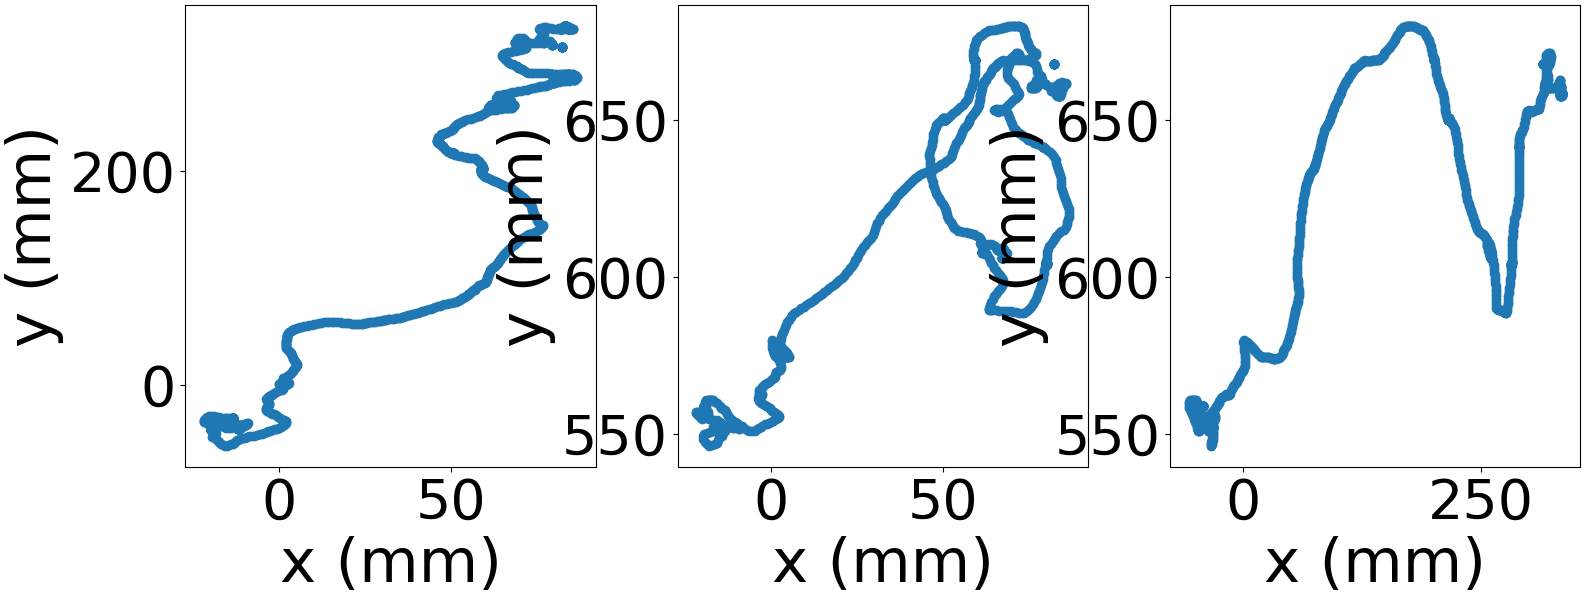

Space between hits:
-0.008179605 -0.028589904 -0.018435512
-0.008179605 -0.028589904 -0.018435512


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,0,51017,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805077,...,-0.008368,-0.007301,-0.005531,-0.0,-0.0,-0.0,0.000151,0.000089,phot,NoProcess
65,0,51016,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805832,...,0.005313,0.040481,0.038972,0.0,0.0,-0.0,0.003108,0.029784,phot,NoProcess
66,0,51015,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.664625,...,0.092126,0.054987,-0.007555,0.0,0.0,-0.0,0.011196,0.387831,phot,NoProcess
67,0,53581,e-,0,1,-13.370129,-31.888691,551.881958,0.522213,-13.391294,...,0.150568,0.004748,-0.025702,-0.0,0.0,-0.0,0.022362,1.291175,eIoni,NoProcess


In [36]:
# Lets look at them quickly, extract some info
for evt, df in hits_5bar.groupby('event_id'):
    fig, axes = plt.subplots(1,3, figsize=(18,6))
    axes[0].scatter(df.x, df.y)
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    
    axes[1].scatter(df.x, df.z)
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    
    axes[2].scatter(df.y, df.z)
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    plt.show()
    
    print('Space between hits:')
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    break

    
    
for evt, df_p in pinfo_5bar.groupby('event_id'):
    display(df_p)
    break

In [6]:
def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits

def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

## clusterise

In [7]:
tagged_hits_5bar = cluster_tagger(hits_5bar, min_samples = 5, scale_xy = 2, scale_z = 2)

In [8]:
first_event = 0

colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig, axes = plt.subplots(1,3, figsize=(18,6))
for (event, cluster), df in tagged_hits_5bar.groupby(['event_id', 'cluster']):
    
    colours = next(colors)
    first_event += 1
    if first_event == 3:
        if cluster == -1:
            continue
        print(f'Event: {event}, Cluster: {cluster}')
        #print(df)
    
    
        axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
        axes[0].set_xlabel('x (mm)')
        axes[0].set_ylabel('y (mm)')
        
        axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
        axes[1].set_xlabel('x (mm)')
        axes[1].set_ylabel('y (mm)')
    
        axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
        axes[2].set_xlabel('x (mm)')
        axes[2].set_ylabel('y (mm)')
        
        axes[2].legend()
    
        plt.show()
        break
    



Event: 1, Cluster: 0


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




<Figure size 1800x600 with 3 Axes>

In [9]:
step = np.sqrt(df['x'].diff()**2 + df['y'].diff()**2 + df['z'].diff()**2)
print(step)

1477         NaN
1478    0.984617
1479    0.999899
1480    0.998771
1481    0.998951
          ...   
3109    0.008387
3110    0.020081
3111    0.003505
3112    0.008418
3113    0.002210
Length: 1588, dtype: float32


## take the biggest cluster, find the maximal distance between the points to collect length

In [10]:
for evt, df in tagged_hits_5bar.groupby('event_id'):
    # check if event has one track larger than 100. If so, include
    if (df.cluster.value_counts() > 100).sum() == 1:
        dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
        df = df[df['cluster'] == dominant_cluster]
        
        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        max_dist = dists[idx]
        pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        
        
        fig, axes = plt.subplots(1,3, figsize=(18,6))
        axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
        axes[0].set_xlabel('x (mm)')
        axes[0].set_ylabel('y (mm)')
    
        axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
        axes[1].set_xlabel('x (mm)')
        axes[1].set_ylabel('z (mm)')
    
        axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
        axes[2].set_xlabel('y (mm)')
        axes[2].set_ylabel('z (mm)')
    
        
        
        axes[0].scatter(pos_a.x, pos_a.y, marker='*', color='red', s=500)
        axes[1].scatter(pos_a.x, pos_a.z, marker='*', color='red', s=500)
        axes[2].scatter(pos_a.y, pos_a.z, marker='*', color='red', s=500, label = 'max distance point B')
        
        axes[0].scatter(pos_b.x, pos_b.y, marker='*', color='blue', s=500)
        axes[1].scatter(pos_b.x, pos_b.z, marker='*', color='blue', s=500)
        axes[2].scatter(pos_b.y, pos_b.z, marker='*', color='blue', s=500, label = 'max distance point A')
        
        axes[2].legend()
        plt.show()
        print(f'evt {evt} max distance {max_dist}mm')
        print(f'maximal positions: {pos_a}, {pos_b}')
    break

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




<Figure size 1800x600 with 3 Axes>

evt 0 max distance 416.6268695322322mm
maximal positions: x     83.345116
y    335.279694
z    658.526917
Name: 1107, dtype: float32, x    -15.783838
y    -57.103268
z    559.597595
Name: 1239, dtype: float32


In [11]:
## and length via true particle information

display(df)
print(df.event_id.unique()[0])
mask = (pinfo_5bar.event_id == df.event_id.unique()[0]) & (pinfo_5bar.creator_proc == 'none')
nubb0_pid = pinfo_5bar[mask]

display(nubb0_pid)
display(nubb0_pid.length.sum())
print(df.particle_id.unique())


fig, axes = plt.subplots(1,3, figsize=(18,6))
axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')

axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('z (mm)')

axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
axes[2].set_xlabel('y (mm)')
axes[2].set_ylabel('z (mm)')



axes[0].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_y, marker='x', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].initial_y, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200, label = 'start point e- 1')

axes[0].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, marker='o', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200, label = 'end point e- 1')


axes[0].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_y, marker='X', color='blue', s=100)
axes[1].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100)
axes[2].scatter(nubb0_pid.iloc[1].initial_y, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100, label = 'start point e- 2')

axes[0].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, marker='o', color='blue', s=200)
axes[1].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200)
axes[2].scatter(nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200, label = 'end point e- 2')


axes[2].legend()
plt.show()


,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1,0
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2,0
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3,0
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
1472,0,-11.836193,-41.254650,552.571167,0.811406,0.000895,ACTIVE,1,240,0
1473,0,-11.834662,-41.255077,552.571106,0.811466,0.000353,ACTIVE,1,241,0
1474,0,-11.833405,-41.255081,552.571167,0.811518,0.000469,ACTIVE,1,242,0
1475,0,-11.832616,-41.254971,552.571228,0.811558,0.000074,ACTIVE,1,243,0


0


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
52,0,2,e-,1,0,0.0,0.0,580.0,0.0,83.194633,...,0.514676,2.211970,-0.476825,0.0,-0.0,0.0,1.865171,614.288391,none,NoProcess
68,0,1,e-,1,0,0.0,0.0,580.0,0.0,-11.830349,...,0.809648,-0.415395,-0.358970,0.0,0.0,0.0,0.592659,185.592941,none,NoProcess


799.88135

[    2 13687 15667 20296 24324 27633 31465 36576 36583 36582 36581 36579
 38654 40312 40374 40373 40372 40371 40370 40369 40368 40367 40366 40365
 40364 40363 40362 40361 41657     1 46508 50974 51026 51025 51024 51023
 51022 51021 51020 51019 51018 51017 51016 51015 53581]


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




<Figure size 1800x600 with 3 Axes>

In [15]:
# extract blob energy by going to final points of the track, 
# calculating the energy around the final point radially, 
# and taking the derivative of that and choosing when the gradient does something funky

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]
#print(point)
threshold = 0.5  # MeV


# hits belonging to the cluster
display(df)

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    
    energies = [df[dists <= r]['energy'].sum() for r in radii]
    return np.array(energies)


radii    = np.linspace(0, 50, 100)
energies_1 = encapsulated_energy(df, point_1, radii)
energies_2 = encapsulated_energy(df, point_2, radii)

# derivative
dE_dr_1 = np.gradient(energies_1, radii)
dE_dr_2 = np.gradient(energies_2, radii)

# find where it flattens — below some threshold
threshold_1   = 0.01 * dE_dr_1.max()  # 1% of peak derivative
flat_idx_1    = np.argmax(dE_dr_1 < threshold)
flat_radius_1 = radii[flat_idx_1]

threshold_2   = 0.01 * dE_dr_2.max()  # 1% of peak derivative
flat_idx_2    = np.argmax(dE_dr_2 < threshold)
flat_radius_2 = radii[flat_idx_2]


# find second derivative
d2E_dr2_1     = np.gradient(dE_dr_1, radii)
inflect_idx_1  = np.argmax(d2E_dr2_1)
inflect_radius_1 = radii[inflect_idx_1]

# find second derivative
d2E_dr2_2     = np.gradient(dE_dr_2, radii)
inflect_idx_2  = np.argmax(d2E_dr2_2)
inflect_radius_2 = radii[inflect_idx_2]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_1)
axes[0].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_1)
axes[1].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_1)
axes[2].axvline(inflect_radius_1, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_1:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_2)
axes[0].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_2)
axes[1].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_2)
axes[2].axvline(inflect_radius_2, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_2:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()

,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1,0
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2,0
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3,0
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
1472,0,-11.836193,-41.254650,552.571167,0.811406,0.000895,ACTIVE,1,240,0
1473,0,-11.834662,-41.255077,552.571106,0.811466,0.000353,ACTIVE,1,241,0
1474,0,-11.833405,-41.255081,552.571167,0.811518,0.000469,ACTIVE,1,242,0
1475,0,-11.832616,-41.254971,552.571228,0.811558,0.000074,ACTIVE,1,243,0


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




<Figure size 1200x500 with 3 Axes>

In [16]:
from scipy.ndimage import gaussian_filter1d

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    return np.array([df[dists <= r]['energy'].sum() for r in radii])

def blob_energy_analysis(df, point, radii, sigma=5):
    energies        = encapsulated_energy(df, point, radii)
    energies_smooth = gaussian_filter1d(energies, sigma=sigma)
    dE_dr           = np.gradient(energies_smooth, radii)
    d2E_dr2         = np.gradient(dE_dr, radii)
    inflect_idx     = np.argmax(d2E_dr2)
    inflect_radius  = radii[inflect_idx]
    inflect_energy  = energies_smooth[inflect_idx]
    return energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, inflect_energy

def plot_blob_analysis(radii, energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, label=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(label)

    axes[0].plot(radii, energies,        alpha=0.4, label='Raw')
    axes[0].plot(radii, energies_smooth, label='Smoothed')
    axes[0].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[0].set_xlabel('Radius')
    axes[0].set_ylabel('Encapsulated Energy')
    axes[0].legend()

    axes[1].plot(radii, dE_dr)
    axes[1].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[1].set_xlabel('Radius')
    axes[1].set_ylabel('dE/dr')
    axes[1].legend()

    axes[2].plot(radii, d2E_dr2)
    axes[2].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[2].set_xlabel('Radius')
    axes[2].set_ylabel('d²E/dr²')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# points
point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii  = np.linspace(0, 50, 200)
sigma  = 3

results_1 = blob_energy_analysis(df, point_1, radii, sigma=sigma)
results_2 = blob_energy_analysis(df, point_2, radii, sigma=sigma)

energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, inflect_energy_1 = results_1
energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, inflect_energy_2 = results_2

plot_blob_analysis(radii, energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, label='Point 1')
plot_blob_analysis(radii, energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, label='Point 2')

print(f'Point 1 blob energy: {inflect_energy_1:.4f}')
print(f'Point 2 blob energy: {inflect_energy_2:.4f}')

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode

(/gluster/home/jwaiton/.cache/matplotlib/tex.cache/450f3a823a1fac85b6700a3157de
c11c.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.5 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 450f3a823a1fac85b6700a3157dec11c.log.




<Figure size 1800x500 with 3 Axes>

In [18]:
def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii     = np.linspace(0, 50, 200)
#threshold = 0.5  # MeV

blob_e_1 = blob_energy_analysis(df, point_1, radii, threshold)
blob_e_2 = blob_energy_analysis(df, point_2, radii, threshold)


blob_r_1 = blob_radius(df, point_1, radii, threshold)
blob_r_2 = blob_radius(df, point_2, radii, threshold)

print(f'Point 1 blob energy: {blob_e_1:.4f}\nPoint 1 blob radius: {blob_r_1:.4f}\n')
print(f'Point 2 blob energy: {blob_e_2:.4f}\nPoint 2 blob radius: {blob_r_2:.4f}\n')

TypeError: unsupported format string passed to tuple.__format__

In [19]:
# how to quantify entanglement?
# naive start: take true length and maximum distance between hits as a ratio.

true_length = nubb0_pid.length.sum()
entanglement = (max_dist / true_length)
print(f'Entanglement: {entanglement*100:.2f}%')


Entanglement: 52.09%


In [28]:
display(df)
display(df_p)
print(list(df_p))

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
1472,0,-11.836193,-41.254650,552.571167,0.811406,0.000895,ACTIVE,1,240
1473,0,-11.834662,-41.255077,552.571106,0.811466,0.000353,ACTIVE,1,241
1474,0,-11.833405,-41.255081,552.571167,0.811518,0.000469,ACTIVE,1,242
1475,0,-11.832616,-41.254971,552.571228,0.811558,0.000074,ACTIVE,1,243


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,0,51017,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805077,...,-0.008368,-0.007301,-0.005531,-0.0,-0.0,-0.0,0.000151,0.000089,phot,NoProcess
65,0,51016,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805832,...,0.005313,0.040481,0.038972,0.0,0.0,-0.0,0.003108,0.029784,phot,NoProcess
66,0,51015,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.664625,...,0.092126,0.054987,-0.007555,0.0,0.0,-0.0,0.011196,0.387831,phot,NoProcess
67,0,53581,e-,0,1,-13.370129,-31.888691,551.881958,0.522213,-13.391294,...,0.150568,0.004748,-0.025702,-0.0,0.0,-0.0,0.022362,1.291175,eIoni,NoProcess


['event_id', 'particle_id', 'particle_name', 'primary', 'mother_id', 'initial_x', 'initial_y', 'initial_z', 'initial_t', 'final_x', 'final_y', 'final_z', 'final_t', 'initial_volume', 'final_volume', 'initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z', 'final_momentum_x', 'final_momentum_y', 'final_momentum_z', 'kin_energy', 'length', 'creator_proc', 'final_proc']


In [30]:
# quantify full energy
print(df.energy.sum())
print(df_p[df_p.particle_id.isin(df.particle_id.values)].kin_energy.sum())

2.2833686
2.937765


[9.9996430e-01 9.9973524e-01 9.9949133e-01 ... 1.2593821e-03 7.9874479e-04
 2.2897022e-03]
0.951926
Average energy deposited
1.55 keV
Median energy deposited
1.17 keV
Maximum energy by a hit
14.99 keV
Total energy (MeV)
2.2833686


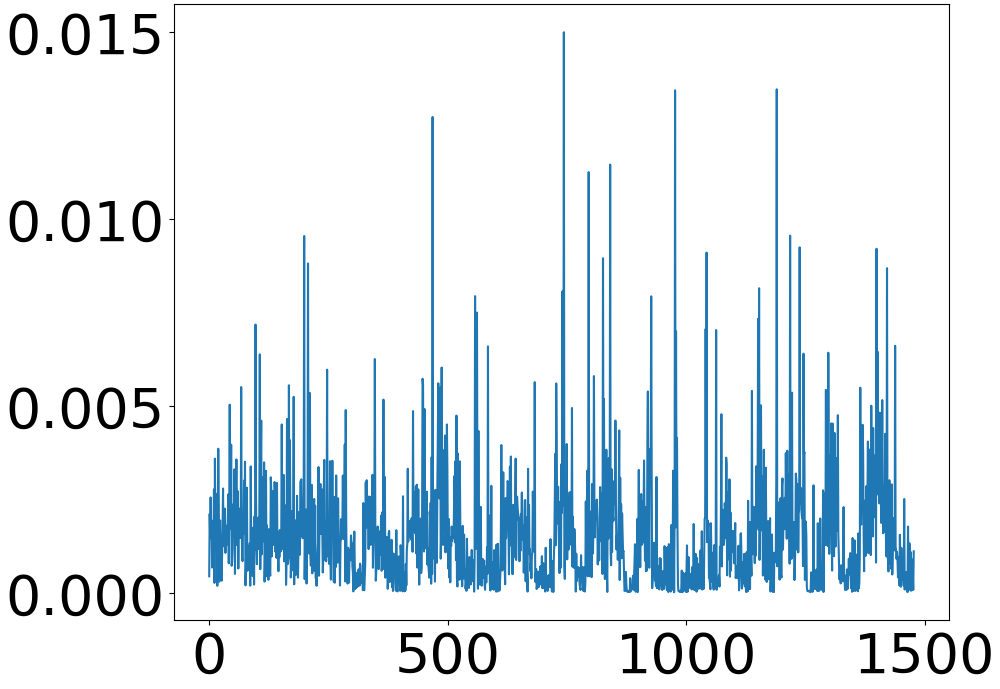

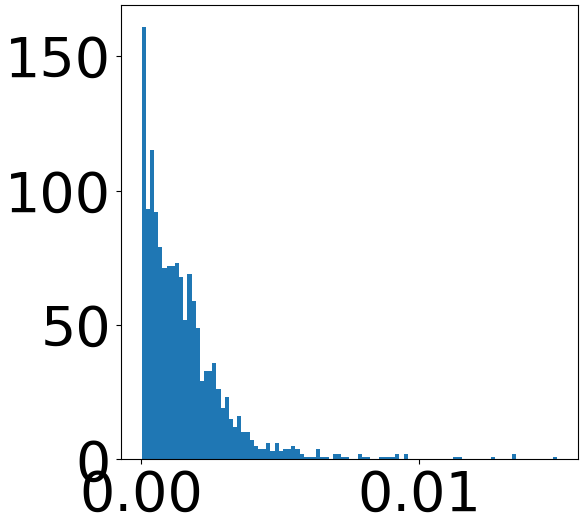

In [78]:
coords = df[['x', 'y', 'z']]
dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
print(dists)
print(np.median(dists))
print('Average energy deposited')
print(f"{np.average(df['energy'])*1000:.2f} keV")
print('Median energy deposited')
print(f"{np.median(df['energy'])*1000:.2f} keV")
print("Maximum energy by a hit")
print(f"{np.max(df['energy'].values)*1000:.2f} keV")
print(f"Total energy (MeV)")
print(df['energy'].sum())
plt.figure(figsize=(10,8))
plt.plot(np.linspace(0, len(df['energy'].values -1), len(df['energy'].values)), df['energy'].values)
plt.show()

plt.hist(df['energy'].values, bins = 100)
plt.show()

In [79]:
!pwd

/gluster/data/next/notebooks/topology_MC_study


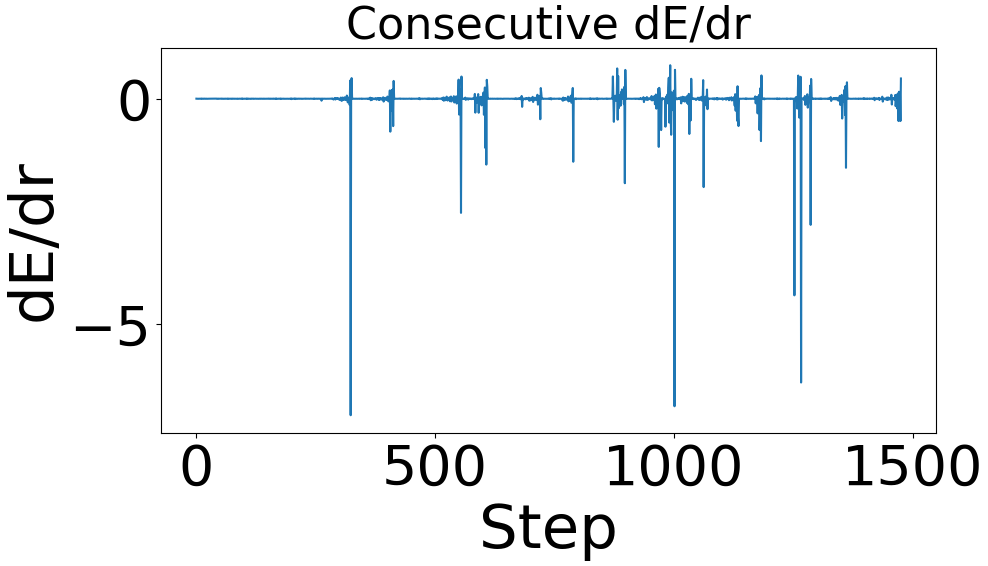

Median dE/dr: -3.27317975461483e-05


In [53]:
# hit energy density is simple
def dE_dr_consecutive(df):
    
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists

def dE_dr_simple(df):
    # assuming dr is always 1
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    # energy per hit, simple
    return energies 


de_dr = dE_dr_consecutive(df)
plt.figure(figsize=(10, 5))
plt.plot(de_dr)
plt.xlabel('Step')
plt.ylabel('dE/dr')
plt.title('Consecutive dE/dr')
plt.show()

print(f'Median dE/dr: {np.median(de_dr)}')

In [54]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path



def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)


# hit energy density is simple
def dE_dr_consecutive(df):
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists


def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]


def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits


def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

def extract_topological_info(hits_df, pinfo_df, threshold = 0.4):
    '''
    Extract entanglement, preferred blob radius 
    radial_threshold in MeV
    '''
    true_lengths   = [] # what the MC particle info gives, end to end
    max_extents    = [] # what are the two furthest apart hits in the track
    entanglements  = [] # max_extents / true_lengths, simply
    blob_1_size    = []
    blob_2_size    = []
    de_drs         = []
    de_drs_simple  = []
    
    # cluster tracks, extract the largest (assuming this is a 0nubb track)
    tagged_hits = cluster_tagger(hits_df, min_samples = 5, scale_xy = 2, scale_z = 2)
    
    for evt, df in tqdm(tagged_hits.groupby('event_id'), total=tagged_hits['event_id'].nunique()):
        # check if event has one track larger than 100. If so, include
        if (df.cluster.value_counts() > 100).sum() == 1:
            dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
            df = df[df['cluster'] == dominant_cluster]
        else:
            continue
            
        ############################################################
        # max extent of track (furthest two hits apart)
        ############################################################

        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        #pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        #pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        max_dist = dists[idx]
        max_extents.append(max_dist)
        
        ############################################################
        # true length of track
        ############################################################
        
        # create mask for specific event
        mask = (pinfo_df.event_id == df.event_id.unique()[0]) & (pinfo_df.creator_proc == 'none')
        nubb0_pid = pinfo_df[mask]
        
        # if it has only two elements, you've done it correctly. If not, something odd has happened.
        # this is because 0nubb is not given a process in MC particle info (lmao)
        if len(nubb0_pid) != 2:
            print(f"More than 2 events explicitly from 0nubb! You've messed up!\ndf: {nubb0_pid}")
            continue
        
        true_length = nubb0_pid.length.sum()
        true_lengths.append(nubb0_pid.length.sum())
        
        ############################################################
        # entanglement
        ############################################################
        entanglement = (max_dist / true_length)
        entanglements.append(entanglement)
        
        ############################################################
        # blob size
        ############################################################
        point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
        point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

        radii     = np.linspace(0, 50, 200)
        
        blob_r_1 = blob_radius(df, point_1, radii, threshold)
        blob_r_2 = blob_radius(df, point_2, radii, threshold)
        
        blob_1_size.append(blob_r_1)
        blob_2_size.append(blob_r_2)
    
        ############################################################
        # dE/dr
        ############################################################
        de_dr = dE_dr_consecutive(df)
        de_drs.append(np.median(de_dr))
        
        de_dr = dE_dr_simple(df)
        de_drs_simple.append(np.median(de_dr))    
    return dict(
                max_extent   = max_extents,
                true_length  = true_lengths,
                entanglement = entanglements,
                blob_1_size  = blob_1_size,
                blob_2_size  = blob_2_size,
                de_dr        = de_drs,
                de_dr_simp   = de_drs_simple)

In [55]:
path_5bar = '/gluster/data/next/files/NEXUS_John/0vbb/4bar/'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 5)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 5)
display(hits_5bar)
display(pinfo_5bar)


,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
7838565,4999,123.592705,10.686277,435.896667,2.619385,0.000098,ACTIVE,1,758
7838566,4999,123.596489,10.687006,435.890991,2.619583,0.001618,ACTIVE,1,759
7838567,4999,123.596260,10.688207,435.891846,2.619642,0.000015,ACTIVE,1,760
7838568,4999,123.595810,10.690542,435.893463,2.619757,0.001285,ACTIVE,1,761


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222654,4999,43607,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.839783,...,-0.015963,-0.013234,-0.007333,-0.0,-0.0,-0.0,0.000473,0.003339,phot,NoProcess
222655,4999,43606,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.870083,...,-0.057298,0.072363,0.060479,0.0,-0.0,0.0,0.011779,0.487257,phot,NoProcess
222656,4999,54751,e-,0,1,124.659485,14.253165,453.109955,2.148500,124.667755,...,0.047024,0.020670,-0.100803,-0.0,-0.0,0.0,0.012374,0.115835,eIoni,NoProcess
222657,4999,60499,e-,0,1,119.512756,6.900838,439.812958,2.485482,119.516144,...,-0.042584,0.118401,0.037350,0.0,-0.0,-0.0,0.016587,0.696750,eIoni,NoProcess


In [56]:
dict_5bar = extract_topological_info(hits_5bar, pinfo_5bar)

  1%|          | 36/5000 [00:03<06:32, 12.64it/s]/tmp/ipykernel_1499239/673022502.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
 67%|██████▋   | 3352/5000 [05:24<02:10, 12.66it/s]/tmp/ipykernel_1499239/673022502.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [08:04<00:00, 10.32it/s]


In [57]:
# 10 bar
path_13bar = '/gluster/data/next/files/NEXUS_John/0vbb/10bar/'

hits_13bar  = load_h5_files(path_13bar, 'MC/hits', 5)
pinfo_13bar = load_h5_files(path_13bar, 'MC/particles', 5)

In [58]:
dict_13bar = extract_topological_info(hits_13bar, pinfo_13bar)

  0%|          | 24/5000 [00:02<07:58, 10.39it/s]/tmp/ipykernel_1499239/673022502.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
 66%|██████▋   | 3320/5000 [04:54<02:19, 12.00it/s]/tmp/ipykernel_1499239/673022502.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [07:22<00:00, 11.31it/s]


In [59]:
def print_histos(dct_5b, dct_13b, key, histo_label, bins = 50):
    '''
    print the histograms for 5 bar and 13 bar based on key
    '''
    # catch NaNs
    arr_5b  = np.array(dct_5b[key],  dtype=float)
    arr_13b = np.array(dct_13b[key], dtype=float)
    
    arr_5b  = arr_5b[np.isfinite(arr_5b)]
    arr_13b = arr_13b[np.isfinite(arr_13b)]
    
    combined = np.concatenate([arr_5b, arr_13b])
    range_   = (combined.min(), combined.max())
    
    plt.hist(dct_5b[key],  alpha=0.5, label='5 bar',  bins=bins, range=range_)
    plt.hist(dct_13b[key], alpha=0.5, label='13 bar', bins=bins, range=range_)
    plt.xlabel(histo_label)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


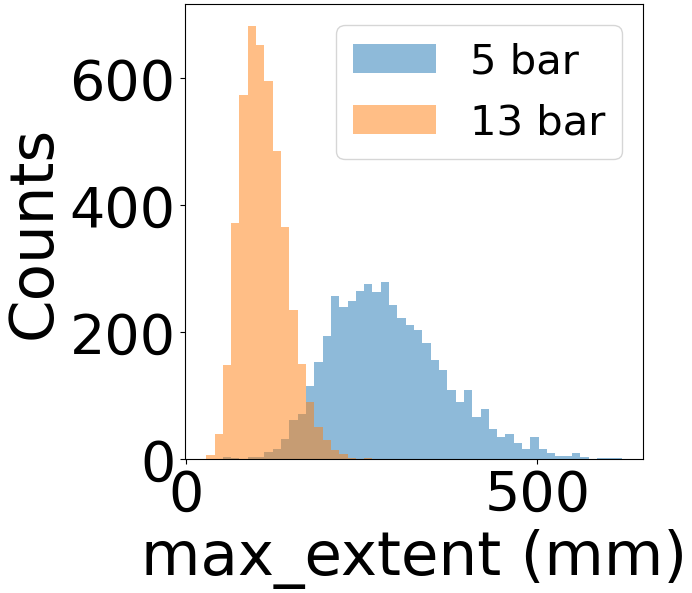

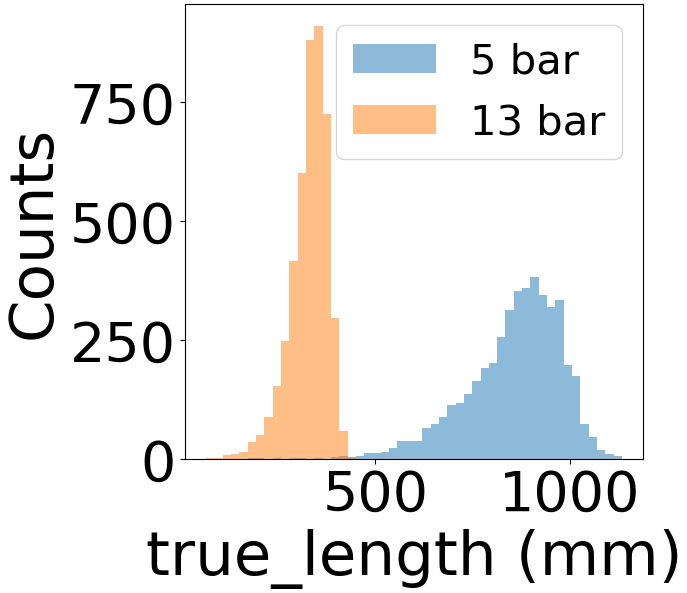

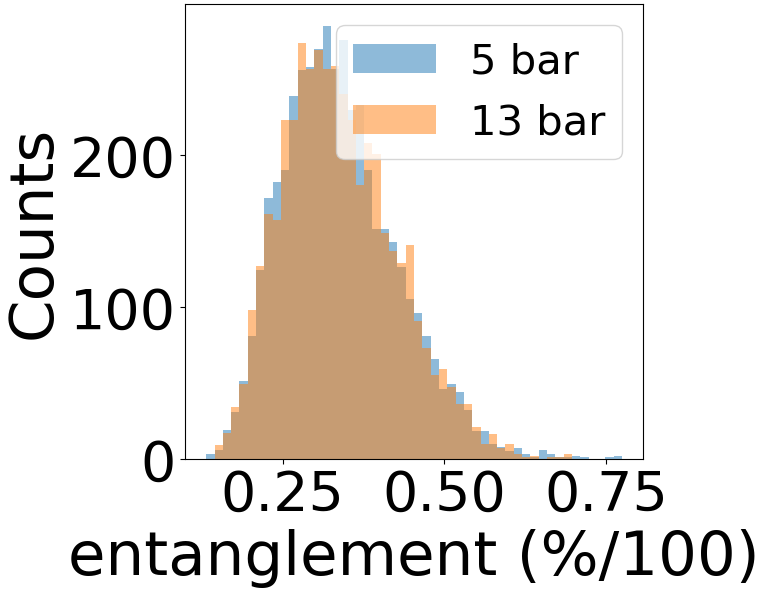

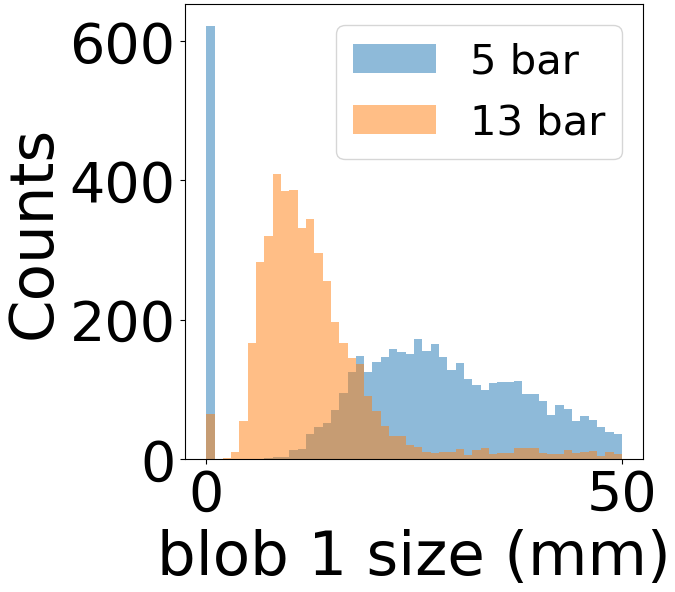

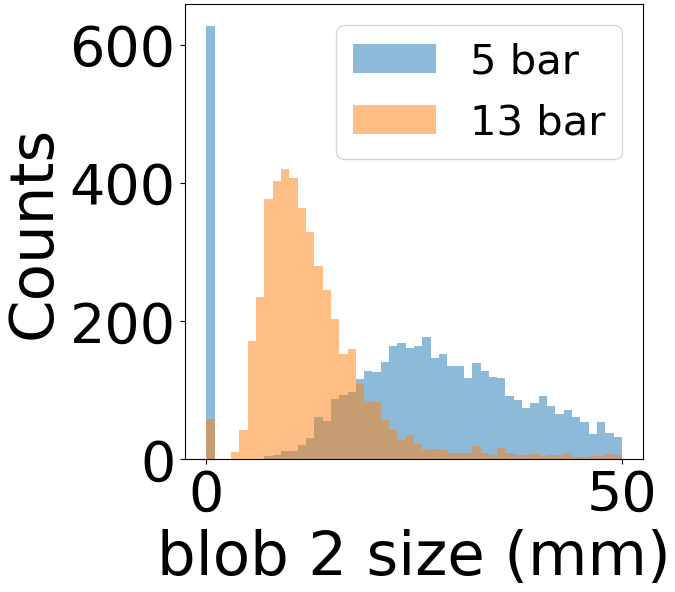

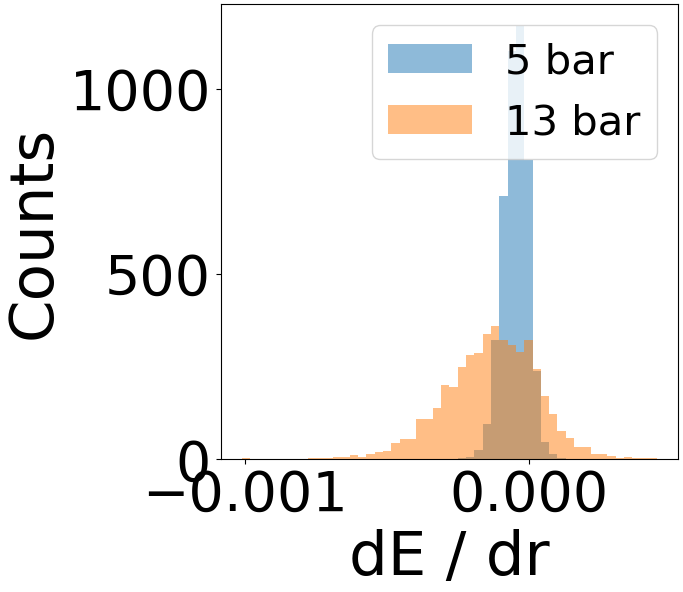

In [60]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print_histos(dict_5bar, dict_13bar, key, str(label))


In [71]:


def print_histos_adv(dct_5b, dct_13b, key, histo_label, bins=50, abs=False):
    if abs:
        arr_5b  = np.abs(np.array(dct_5b[key],  dtype=float))
        arr_13b = np.abs(np.array(dct_13b[key], dtype=float))
    else:
        arr_5b  = np.array(dct_5b[key],  dtype=float)
        arr_13b = np.array(dct_13b[key], dtype=float)

    arr_5b  = arr_5b[np.isfinite(arr_5b)]
    arr_13b = arr_13b[np.isfinite(arr_13b)]

    if key in ('blob_1_size', 'blob_2_size'):
        arr_5b  = arr_5b[arr_5b   >= 1]
        arr_13b = arr_13b[arr_13b >= 1]

    if key in ('de_dr'):
        print('de_dr we did it')
        arr_5b = arr_5b * 1000
        arr_13b = arr_13b * 1000
    combined = np.concatenate([arr_5b, arr_13b])
    range_   = (combined.min(), combined.max())

    plt.hist(arr_5b,  alpha=0.5, label='4 bar',  bins=bins, range=range_)
    plt.hist(arr_13b, alpha=0.5, label='10 bar', bins=bins, range=range_)
    plt.xlabel(histo_label)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()
    print(f'Median for 10 bar: {np.median(arr_13b)}')
    print(f'Mean for 10 bar: {np.average(arr_13b)}')
    print(f'Median for 4 bar: {np.median(arr_5b)}')
    print(f'Mean for 4 bar: {np.average(arr_5b)}')
    


max_extent


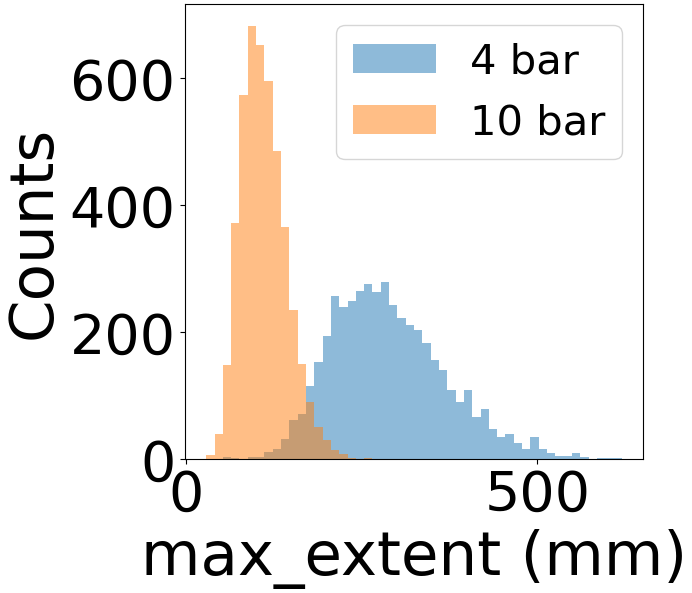

Median for 10 bar: 107.56304468050698
Mean for 10 bar: 110.86751121370276
Median for 4 bar: 280.0638163755697
Mean for 4 bar: 288.77378993155514
true_length


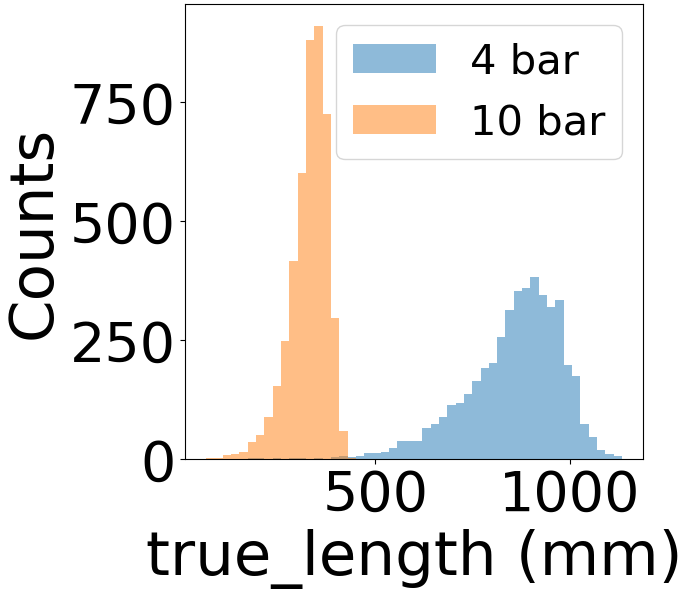

Median for 10 bar: 337.32208251953125
Mean for 10 bar: 329.2955514154914
Median for 4 bar: 877.3142700195312
Mean for 4 bar: 857.2839690757903
entanglement


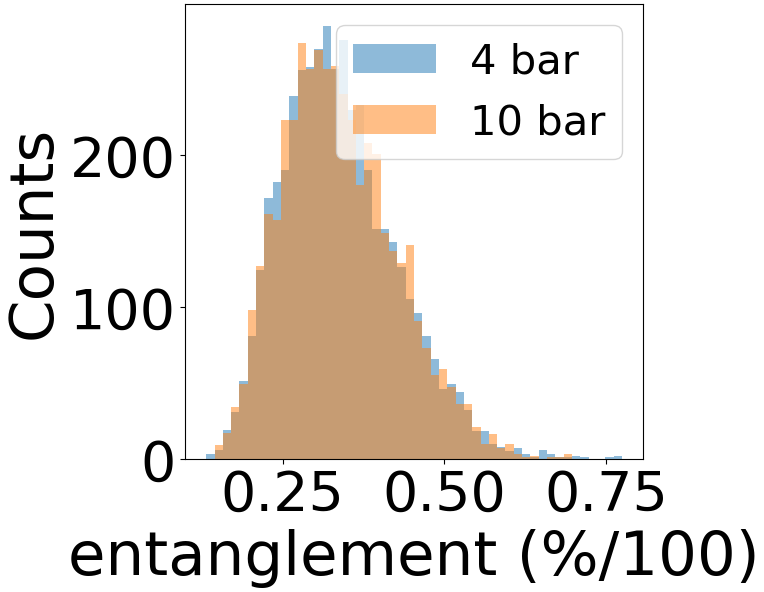

Median for 10 bar: 0.32922413098577064
Mean for 10 bar: 0.3385519370787326
Median for 4 bar: 0.32874991894102756
Mean for 4 bar: 0.33892104472086493
blob_1_size


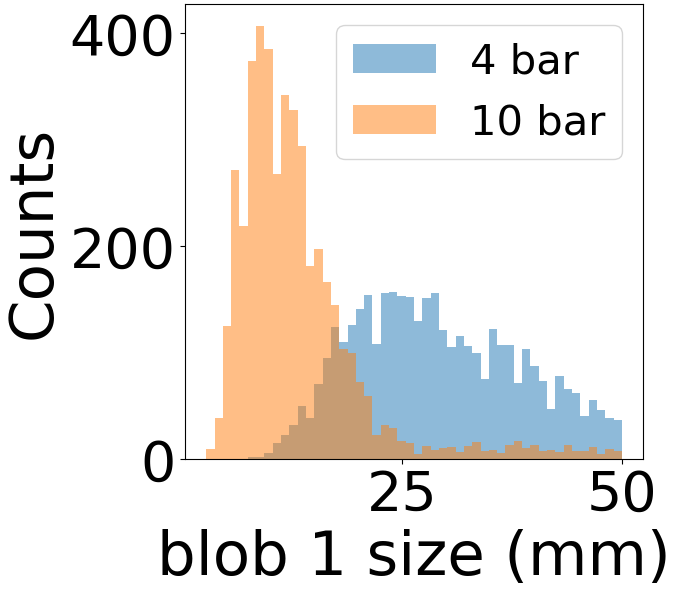

Median for 10 bar: 11.557788944723617
Mean for 10 bar: 13.197733984893988
Median for 4 bar: 27.889447236180903
Mean for 4 bar: 29.078799833353045
blob_2_size


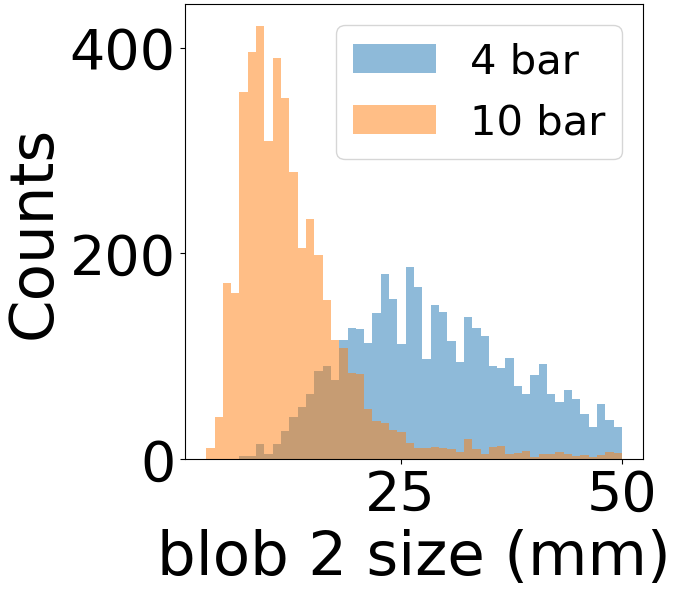

Median for 10 bar: 11.306532663316581
Mean for 10 bar: 12.893140182427011
Median for 4 bar: 27.889447236180903
Mean for 4 bar: 28.89241235642728
de_dr
de_dr we did it


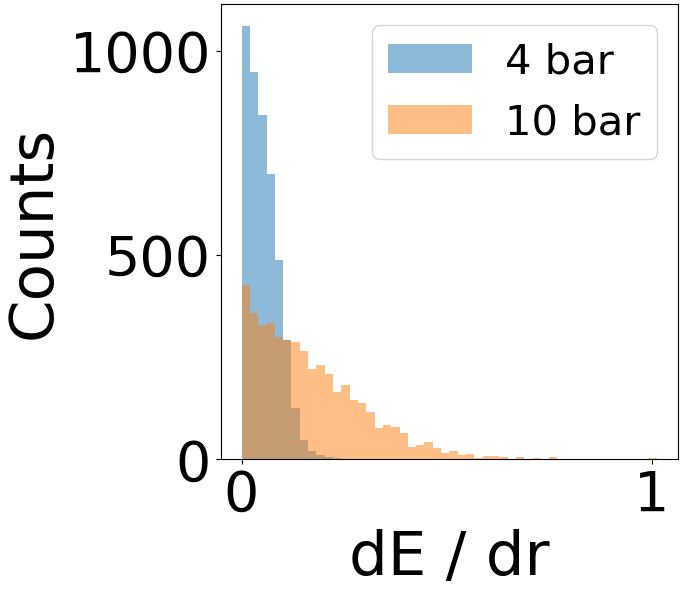

Median for 10 bar: 0.13618491357192397
Mean for 10 bar: 0.16282057435274203
Median for 4 bar: 0.04667812027037144
Mean for 4 bar: 0.05203976034389202


In [72]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print(key)
    if key in ('de_dr'):
        print_histos_adv(dict_5bar, dict_13bar, key, str(label), abs = True)
    else:
        print_histos_adv(dict_5bar, dict_13bar, key, str(label))


In [73]:
import pickle

with open('dict_4bar.pkl', 'wb') as f:
    pickle.dump(dict_5bar, f)

with open('dict_10bar.pkl', 'wb') as f:
    pickle.dump(dict_13bar, f)